# Kineret — Complication Prediction

**Task.** Observe the first **K days** of an admission; predict, per
complication, whether it occurs before day 14, **when**, and how long the stay
will be.

```text
inputs :  events in [0, K*24]                hours from ADMISSION
labels :  outcome occurs in (K*24, 14*24]    hours from ADMISSION
```

**K is a training-time augmentation, not a sweep.** Each training admission
contributes one sample per context window it reaches — the same trajectory cut
at a different point, with the label window re-derived to match — so the model
learns to forecast from however much history it has. The augmentation is
deliberately **ragged**: a patient discharged on day 5 has no day-7 cut to make,
so long stays contribute more samples than short ones. Cohort membership keys on
the *evaluation* window only, so widening the augmentation adds samples and never
removes patients.

**Evaluation happens at a single window**, chosen in §2 from the support table
before any training starts. Every reported number comes from that one window, so
the results are a table, not a surface.

## The seven arms

| Rung | Arm | Input |
|---|---|---|
| 1 | LogReg (raw) | raw measurements, distribution-summarised |
| 2 | LogReg (raw + QA) | + aggregated compliance in the context vector |
| 3 | ss-STraTS (raw) | raw measurements + learned temporal attention |
| 4 | ss-STraTS (raw + QA) | + aggregated compliance in the context vector |
| 5 | INTERVenE-Enc (σ-bins) | knowledge-**free** intervals over the same raw data |
| 6 | INTERVenE-Enc (KB) | knowledge-**based** Mediator abstractions |
| 7 | INTERVenE-Enc (KB + QA) | + treatment-quality pattern tokens |

Rungs 5 → 6 isolate the knowledge base. Rungs 6 → 7 isolate the treatment
signal. Rungs 2/4 ask the same QA question of the models that cannot represent
pattern tokens, so the QA effect is separable from the architecture.

Every arm answers the same three questions, on the same patients, with the same
labels, over the same reconciled event set.

---

**Run order.** §1 config → §2 support and window choice → §3 wiring check →
§4 the ladder. §5 onward reads from `outputs/` and can be re-run freely.

**Resume.** §4 skips any arm that already has a `test_predictions.csv`. If the
kernel dies, re-run that one cell and it continues from where it stopped.

**Memory.** Each arm is trained, scored, written to disk and released. Nothing
is held across cells.

**Figures.** Every figure and its underlying table are written to
`outputs/figures/` as PNG + PDF + CSV, ready for the paper.

## 1 · Study configuration

**This cell is the experimental design.** Everything shared between models is
set here and nowhere else — windows, targets, date range, event reconciliation,
QA aggregation, seeds. Per-model hyperparameters stay with their model
(`kineret/strats/config.py`, `kineret/intervene/config/model_config.py`,
`kineret/logreg/train.py`).

`TARGETS` is the study's target list. It ships as every clinical complication
the Mediator knowledge base can emit, minus structural framing and treatment
administrations — **trim it to the paper's list here.** §2 shows which entries
clear the support floor; only those get a prediction head.

In [1]:
import gc, os, sys, warnings
sys.path.insert(0, os.path.abspath(".."))
warnings.filterwarnings("ignore", category=FutureWarning)

# --- Synthetic data (optional) -------------------------------------------
# Uncomment to exercise the whole pipeline without the real Kineret drop.
# !python ../scripts/make_synthetic_data.py --patients 400 --out ../data/source_synth
# for key, nm in [("RAW_TEMPORAL", "mediator_input"), ("ABSTRACT", "mediator_output"),
#                 ("CONTEXT", "context_data"), ("QA", "qa_scores")]:
#     os.environ[f"KINERET_{key}"] = os.path.abspath(f"../data/source_synth/{nm}.csv")

from kineret.config import data_config as C
from kineret.config import paths

# ===========================================================================
#  THE STUDY DESIGN -- edit here, nowhere else
# ===========================================================================
TARGETS = [
    "CARDIO-VASCULAR_DISORDER_EVENT",
    "DEATH_EVENT",
    "HYPERGLYCEMIA_EVENT",
    "HYPEROSMOLALITY_EVENT",
    "HYPOGLYCEMIA_EVENT",
    "INFECTION_EVENT",
    "KETOACIDOSIS_EVENT",
    "KIDNEY_COMPLICATION_EVENT",
    "SEVERE_HYPERGLYCEMIA_EVENT",
    "SEVERE_HYPOGLYCEMIA_EVENT",
]

# ===========================================================================
#  RAW-SIDE EVENT DERIVATION
# ===========================================================================
# mediator_input.csv holds measurements, not complications: the Mediator is what
# turns a glucose reading into HYPERGLYCEMIA_EVENT. Without the raw file's own
# view of those events the two files have nothing to agree on, and the
# cross-file intersection is a no-op for exactly the targets that carry the
# study.
#
# The rules are NOT written here. They are compiled from the Mediator's own
# knowledge base and executed verbatim, because the Mediator produced
# mediator_output.csv FROM mediator_input.csv -- so any disagreement is a
# reproduction defect, never a source conflict, and section 2 refuses to
# continue on one.
#
#   python -m kineret.mediator_rules <path-to>/Mediator/core/knowledge-base
#
# ships kineret/config/event_rules.json. Point MEDIATOR_KB_PATH at a live
# checkout to compile from the XML at run time instead -- the safer choice if
# the knowledge base has moved on since this package was built.
MEDIATOR_KB_PATH = None      # e.g. "/workspace/Mediator/core/knowledge-base"

study = C.configure_study(
    # --- windows ---------------------------------------------------------
    # Training augmentation: one sample per window each patient reaches.
    # The range spans the whole horizon -- every window is a real cut of data
    # already collected, and membership does not depend on it, so a wide range
    # costs nothing and buys samples.
    train_context_days=list(range(1, 14)),   # 1..13
    eval_context_days=4,                     # single; revisit after §2
    horizon_end_days=14.0,

    # K sets both how much history a sample gets and how far ahead it forecasts.
    # Hand both to the model rather than making it infer them.
    add_context_length_features=True,

    # --- cohort ----------------------------------------------------------
    date_range_start="2022-07-01",
    date_range_end="2025-12-31",
    date_range_require_full_horizon=True,

    # --- targets ---------------------------------------------------------
    targets=TARGETS,
    auto_discover_outcomes=False,            # the list above is the list
    outcome_support_threshold=0.01,          # 1 % of train patients

    # Every OTHER `*_EVENT` the Mediator emits (AKI, ELECTROLYTE_DERANGEMENT,
    # MYOCARDIAL_INJURY, ...) is a KB conclusion, not a target. It stays in the
    # KB arms' input and is stripped from everyone else's: handing a derived
    # clinical judgement to LogReg or ss-STraTS would make the ladder measure a
    # leak instead of the value of abstraction.
    kb_events_for_kb_arms_only=True,

    # --- shared data contract -------------------------------------------
    event_source="mediator",                 # whose event verdict wins
    event_match_tolerance_h=24.0,            # clinical: same event restated

    # For a target BOTH files carry, credit only the occurrences they date
    # identically -- this is what removes the 3096-vs-3098 support drift.
    # Targets only one file carries (the Mediator-derived ones) pass through.
    event_align_across_files=True,
    event_align_tolerance_min=1.0,           # clock skew between two exports

    # Rebuild the raw file's own view of every complication FIRST, so the
    # intersection above has something to intersect for all ten targets.
    derive_raw_events=True,
    mediator_kb_path=MEDIATOR_KB_PATH,
    # The derived view must reproduce the Mediator exactly. Anything less means
    # a rule is being executed wrongly, and the intersection would silently
    # delete real labels -- so the build stops instead.
    rule_agreement_min=1.0,
    raise_on_rule_mismatch=True,
    events_as_inputs=True,                   # in-window events are history
    qa_aggregations=["mean"],                 # compliance -> context vector

    # --- identity --------------------------------------------------------
    # The Mediator carries one id column, so the temporal tables key on the
    # ADMISSION. The context table keys on VisitId and names the person too.
    context_id_column="VisitId",
    context_person_column="person_id",
    # One person's admissions never straddle the split -- otherwise the test
    # score partly measures having memorised that person from training.
    split_group_by_person=True,

    # --- reproducibility -------------------------------------------------
    split_seed=2023,
    seed=2023,
)

BOOTSTRAP = 2000        # resamples for every reported interval
print(C.study_summary())

study window        : 2022-07-01 .. 2025-12-31  (full horizon required: True)
training windows    : K in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13] days  (augmentation: one sample per K the patient reaches)
evaluation window   : K = 4 days  (single; all reported numbers)
label window        : (K*24, 14*24] hours from admission
candidate targets   : 10  (support-filtered at 1% on train)
event reconciliation: 'mediator', tolerance 24 h, events as inputs: True
QA aggregation      : ['mean']
seeds               : split=2023, run=2023


In [2]:
# ---------------------------------------------------------------------
#  Absolute path to the Mediator's knowledge base, or None for the
#  rules that ship with this package.
#     e.g. "/workspace/notebooks/code/Mediator/core/knowledge-base"
# ---------------------------------------------------------------------
MEDIATOR_KB = "/workspace/notebooks/code/mediator-deploy/core/knowledge-base"

import json as _json, os as _os
from kineret import raw_events as _raw_events
from kineret.mediator_rules import parse_knowledge_base

if MEDIATOR_KB:
    kb = _os.path.abspath(_os.path.expanduser(MEDIATOR_KB))
    # Accept a repo root or a core/ directory too, so a slightly-off path is
    # corrected rather than compiling to an empty rule set.
    for candidate in (kb,
                      _os.path.join(kb, "knowledge-base"),
                      _os.path.join(kb, "core", "knowledge-base")):
        if _os.path.isdir(_os.path.join(candidate, "events")):
            kb = candidate
            break
    else:
        raise FileNotFoundError(
            f"No 'events/' directory under {kb}. Point MEDIATOR_KB at the "
            f"knowledge-base folder itself, e.g. "
            f".../Mediator/core/knowledge-base")

    compiled = parse_knowledge_base(kb)
    out_path = _raw_events.rules_path()
    with open(out_path, "w", encoding="utf-8") as handle:
        _json.dump(compiled, handle, indent=1, sort_keys=True)
    _raw_events._RULES_CACHE.clear()      # so the next cell reads the new file
    print(f"[rules] compiled from {kb}")
    print(f"[rules] {len(compiled['events'])} events, "
          f"{len(compiled['clippers'])} concept ranges -> {out_path}\n")
else:
    compiled = _raw_events.load_rules()
    print(f"[rules] using the rules shipped with the package "
          f"({_raw_events.rules_path()})\n")

# The definitions every label depends on -- read them.
for _name in TARGETS:
    _spec = compiled["events"].get(_name)
    if _spec is None:
        print(f"  {_name:<32} NO RULE -- this target cannot be reproduced")
        continue
    for _rule in _spec["rules"]:
        _parts = []
        for _clause in _rule["clauses"]:
            _kind = (_clause["transform"] or {}).get("kind", "value")
            _bounds = ", ".join(
                (f"{_c['type']}={_c['value']}" if "value" in _c
                 else f"range=[{_c['min']}, {_c['max']}]")
                for _c in _clause["constraints"])
            _parts.append(f"{_clause['source']}[{_kind}] {_bounds}")
        print(f"  {_name:<32} {_rule['operator']}( " + "  |  ".join(_parts) + " )")
        if _rule.get("unsupported"):
            print(f"      UNSUPPORTED: {_rule['unsupported']} -- section 4 "
                  f"will refuse to build")

_missing_ranges = [c for c in ("GLUCOSE_MEASURE", "CREATININE_SERUM_MEASURE")
                   if not compiled["clippers"].get(c)]
if _missing_ranges:
    print(f"\n[rules] WARNING: no validity range for {_missing_ranges}; "
          f"out-of-range readings will reach the rules.")


[rules] compiled from /workspace/notebooks/code/mediator-deploy/core/knowledge-base
[rules] 28 events, 27 concept ranges -> /workspace/notebooks/code/Predictions/kineret-prediction/kineret/config/event_rules.json

  CARDIO-VASCULAR_DISORDER_EVENT   or( CARDIO-VASCULAR_DISORDER[value] equal=True )
  DEATH_EVENT                      or( DEATH[value] equal=True )
  HYPERGLYCEMIA_EVENT              or( GLUCOSE_MEASURE[value] min=250.0  |  GLUCOSE_MEASURE[sustained] min=180.0 )
  HYPEROSMOLALITY_EVENT            or( HYPEROSMOLALITY[value] equal=True )
  HYPOGLYCEMIA_EVENT               or( GLUCOSE_MEASURE[value] max=54.0  |  GLUCOSE_MEASURE[sustained] max=70.0 )
  INFECTION_EVENT                  or( INFECTION[value] equal=True )
  KETOACIDOSIS_EVENT               or( KETOACIDOSIS[value] equal=True )
  KIDNEY_COMPLICATION_EVENT        or( CREATININE_SERUM_MEASURE[ratio_to_baseline] min=2.0  |  CREATININE_SERUM_MEASURE[value] min=4.0  |  KIDNEY_COMPLICATION[value] equal=True )
  SEVERE_HYPER

In [3]:
from kineret.benchmark import ARMS, resolve_device, free_memory, save_table

DEVICE = resolve_device()          # warns loudly if this lands on CPU
print()
for key, model, use_qa, label in ARMS:
    print(f"  rung {ARMS.index((key, model, use_qa, label)) + 1}  "
          f"{label:<32} model={model:<18} qa={use_qa}")
print()
print("Source tables (drop them in data/source/ under these exact names):")
print(paths.describe_sources())

[device] cuda -- Tesla T4 (14.6 GiB)

  rung 1  LogReg (raw)                     model=logreg             qa=False
  rung 2  LogReg (raw + QA)                model=logreg             qa=True
  rung 3  ss-STraTS (raw)                  model=strats             qa=False
  rung 4  ss-STraTS (raw + QA)             model=strats             qa=True
  rung 5  INTERVenE-Enc (σ-bins)           model=intervene_enc_std  qa=False
  rung 6  INTERVenE-Enc (KB)               model=intervene_enc      qa=False
  rung 7  INTERVenE-Enc (KB + QA)          model=intervene_enc      qa=True

Source tables (drop them in data/source/ under these exact names):
  [ok     ] mediator_input   /workspace/notebooks/code/Predictions/kineret-prediction/data/source/mediator_input.csv
  [ok     ] mediator_output  /workspace/notebooks/code/Predictions/kineret-prediction/data/source/mediator_output.csv
  [ok     ] context_data     /workspace/notebooks/code/Predictions/kineret-prediction/data/source/context_data.csv
  [ok   

## 2 · Rule check — before anything expensive

The Mediator built `mediator_output.csv` from `mediator_input.csv`. This
cell re-executes its own compiled rules on a sample of admissions and
checks the result matches, occurrence for occurrence.

**Every target must read 100%.** `raw_only` events were invented by the
reproduction; `med_only` events were missed. Either one means a rule is
being executed wrongly, and the cross-file intersection later would delete
real labels rather than filter doubtful ones — so section 3 refuses to
build the cohort until this is clean.

Runs on a sample so a wrong rule surfaces in under a minute instead of
after a full cohort build.

In [4]:
from kineret.raw_events import validate_rules

# n_admissions=0 checks every admission; a sample is enough to catch a
# wrong threshold and is much faster on the full extract.
rule_report = validate_rules(n_admissions=5000)
save_table(rule_report, "rule_agreement")

assert (rule_report["agreement"] >= 1.0).all(), (
    "Some targets do not reproduce the Mediator exactly -- see the table "
    "above. Fix the rule before continuing; do not relax the threshold.")
free_memory()

[validate] reading source tables...
[validate] 5,000 admissions sampled (1,212,892 raw rows / 980,878 mediator rows).
[derive] CARDIO-VASCULAR_DISORDER_EVENT           616 events  (148 admissions)  CARDIOVASCULAR_DISORDER[value]=1,030
[derive] DEATH_EVENT                              162 events  (162 admissions)  DEATH[value]=162
[derive] HYPERGLYCEMIA_EVENT                   37,875 events  (4,119 admissions)  GLUCOSE_MEASURE[value]=21,887 | GLUCOSE_MEASURE[sustained]=32,973
[derive] HYPEROSMOLALITY_EVENT                     92 events  (48 admissions)  HYPEROSMOLALITY[value]=133
[derive] HYPOGLYCEMIA_EVENT                       549 events  (299 admissions)  GLUCOSE_MEASURE[value]=355 | GLUCOSE_MEASURE[sustained]=286
[derive] INFECTION_EVENT                          223 events  (216 admissions)  INFECTION[value]=223
[derive] KETOACIDOSIS_EVENT                       242 events  (74 admissions)  KETOACIDOSIS[value]=243
[derive] KIDNEY_COMPLICATION_EVENT              2,416 events  (785 adm

In [5]:
import json, pandas as pd
from kineret.config import paths

taks = set(json.load(open(paths.TAK_REPO_PATH, encoding="utf-8"))["taks"])
abstract = pd.read_csv(paths.ABSTRACT_FILE, usecols=["ConceptName"])
missing = sorted(set(abstract["ConceptName"]) - taks)
print(f"TAK repo: {len(taks)} concepts | mediator_output: {abstract['ConceptName'].nunique()} distinct")
print("missing from TAK:", missing or "none")

TAK repo: 174 concepts | mediator_output: 102 distinct
missing from TAK: none


## 3 · Target support — choosing the evaluation window

**Run this before training.** It builds the cohort and shows, for every
candidate window, how many positives each target still has in that window's
label range `(K, 14]`.

The trade-off is direct: a larger K gives the model more history but leaves a
shorter label window, and the rare complications lose positives first. The
number that matters is how many targets still clear the support floor — those
are the ones that get a prediction head.

The reconciliation audit below it is the other thing to check: the raw file and
the Mediator output disagree about how often each complication fired, and this
is where that is resolved into one canonical event set used by every arm.

In [6]:
import pandas as pd
from kineret.benchmark import ensure_prepared, target_support
from kineret import figures

cohort = ensure_prepared()
support = target_support(cohort)

print(f"\nCohort: {len(cohort.patients):,} patients")
samples = cohort.samples()
for split in ("train", "val", "test"):
    rows = samples[samples["split"] == split]
    print(f"  {split:<5}: {len(rows):>6,} samples over "
          f"{rows['PatientId'].nunique():>5,} patients "
          f"(K={sorted(rows['k'].unique())})")
print(f"\nTargets with a head at K={C.EVAL_CONTEXT_DAYS}: "
      f"{len(cohort.outcome_names)} of {len(TARGETS)}")
print("  kept    : " + ", ".join(cohort.outcome_names))
if cohort.dropped_outcomes:
    print("  dropped : " + ", ".join(
        f"{k} ({v:.2%})" for k, v in sorted(cohort.dropped_outcomes.items(),
                                            key=lambda kv: -kv[1])))

[prepare] Reusing /workspace/notebooks/code/Predictions/kineret-prediction/data/processed/cohort.pkl
[prepare] ss-STraTS pickles already present.
[Cohort] harmonise_events: 23,109 outcome rows -> 161,098 canonical rows.
[abstraction] Reusing /workspace/notebooks/code/Predictions/kineret-prediction/data/processed/std_temporal_data.csv
[prepare] Ready: 50,118 patients, 8 targets, 179,141 training samples from 35,125 patients (5.1 per patient), evaluation at K=4.
[prepare] 31,175/50,118 patients reach the evaluation window and can be scored; the rest are training-only.
[prepare] Samples per training window (ragged -- a patient contributes a window only if their stay reaches it):
            K1:35125  K2:35123  K3:28792  K4:21889  K5:16571  K6:12526  K7:9314  K8:6737  K9:4957  K10:3505  K11:2417  K12:1473  K13:712

Cohort: 50,118 patients
  train: 179,141 samples over 35,125 patients (K=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8),

[figure] /workspace/notebooks/code/Predictions/kineret-prediction/outputs/figures/fig1_target_support.png
[table]  /workspace/notebooks/code/Predictions/kineret-prediction/outputs/figures/fig1_target_support.csv


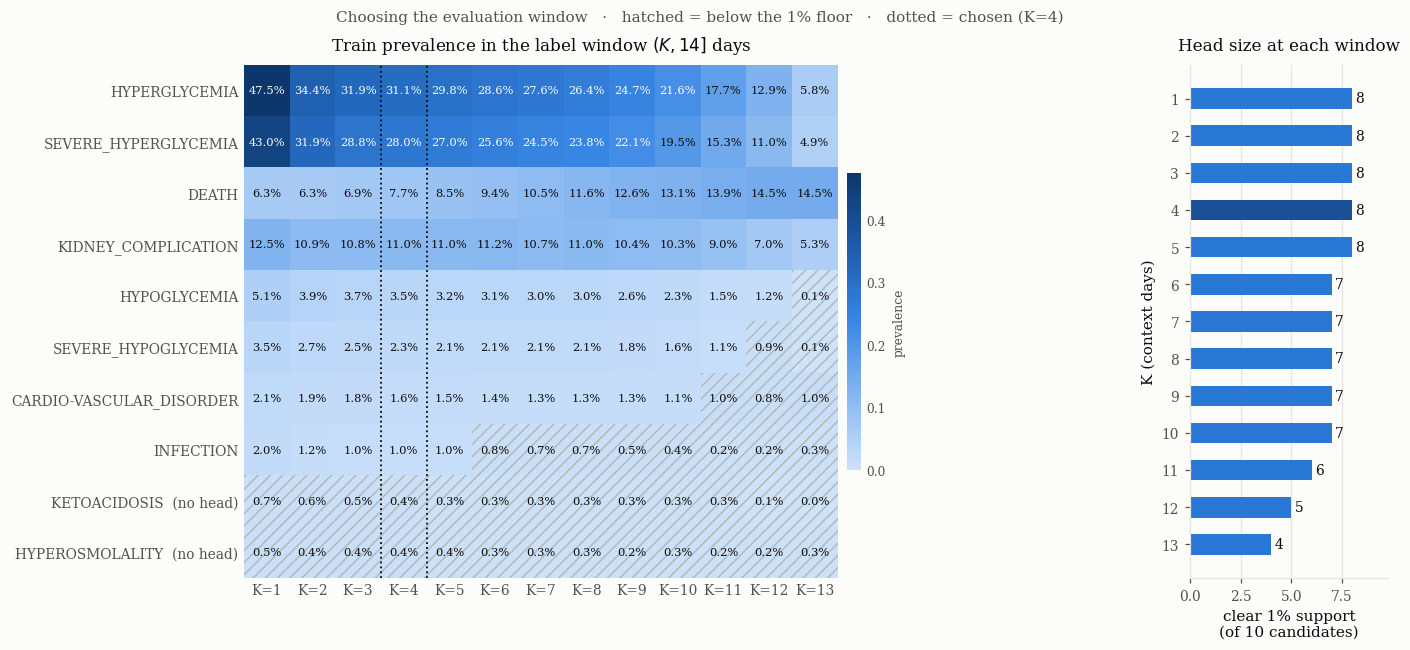

In [7]:
figures.plot_target_support(support);

In [8]:
print("Event reconciliation -- the two source files, and the canonical result:")
save_table(cohort.event_audit, "cohort_event_audit")
cohort.event_audit

Event reconciliation -- the two source files, and the canonical result:
[table]  /workspace/notebooks/code/Predictions/kineret-prediction/outputs/figures/cohort_event_audit.csv


,outcome,n_raw,n_mediator,n_canonical,source,patients_raw,patients_mediator,patients_canonical,raw_before,raw_after,mediator_before,mediator_after
0,CARDIO-VASCULAR_DISORDER_EVENT,2854,2854,2854,mediator,1504,1504,1504,7149,7149,7149,7149
1,DEATH_EVENT,3098,3098,3098,mediator,3098,3098,3098,3098,3098,3098,3098
2,HYPERGLYCEMIA_EVENT,68525,68525,68525,mediator,41911,41911,41911,402044,402044,402044,402044
3,HYPEROSMOLALITY_EVENT,814,814,814,mediator,602,602,602,1525,1525,1525,1525
4,HYPOGLYCEMIA_EVENT,4223,4223,4223,mediator,3531,3531,3531,7564,7564,7564,7564
5,INFECTION_EVENT,3345,3345,3345,mediator,3234,3234,3234,3345,3345,3345,3345
6,KETOACIDOSIS_EVENT,1116,1116,1116,mediator,710,710,710,2597,2597,2597,2597
7,KIDNEY_COMPLICATION_EVENT,18206,18206,18206,mediator,9877,9877,9877,33463,33463,33463,33463
8,SEVERE_HYPERGLYCEMIA_EVENT,56717,56717,56717,mediator,34172,34172,34172,224187,224187,224187,224187
9,SEVERE_HYPOGLYCEMIA_EVENT,2908,2908,2908,mediator,2480,2480,2480,4712,4712,4712,4712


### Confirm the window

If §2 says a different K is the right call, change `eval_context_days` in §1 and
re-run from there. The cohort and the support filter both depend on it, so it
has to be settled before §4.

In [9]:
print(f"Evaluating at K={C.EVAL_CONTEXT_DAYS}: observe days 0-{C.EVAL_CONTEXT_DAYS}, "
      f"predict days {C.EVAL_CONTEXT_DAYS}-{C.HORIZON_END_DAYS:.0f}.")
print(f"Training augmented over K={list(C.TRAIN_CONTEXT_DAYS)}.")
free_memory()

Evaluating at K=4: observe days 0-4, predict days 4-14.
Training augmented over K=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13].


## 5 · Train the ladder — one cell

All seven arms, trained and scored end to end. This is the expensive cell and
the only one that trains anything.

* **Resumable** — arms with existing predictions are skipped. Delete an arm's
  directory under `outputs/` to force a retrain.
* **Memory-bounded** — each arm is released after scoring.
* **Fault-tolerant** — a failed arm is logged and the run continues; check the
  `status` column.
* Progress is written to `outputs/run_ladder_log.csv` after every arm.

[prepare] Reusing /workspace/notebooks/code/Predictions/kineret-prediction/data/processed/cohort.pkl
[prepare] ss-STraTS pickles already present.
[Cohort] harmonise_events: 23,109 outcome rows -> 161,098 canonical rows.
[abstraction] Reusing /workspace/notebooks/code/Predictions/kineret-prediction/data/processed/std_temporal_data.csv
[prepare] Ready: 50,118 patients, 8 targets, 179,141 training samples from 35,125 patients (5.1 per patient), evaluation at K=4.
[prepare] 31,175/50,118 patients reach the evaluation window and can be scored; the rest are training-only.
[prepare] Samples per training window (ragged -- a patient contributes a window only if their stay reaches it):
            K1:35125  K2:35123  K3:28792  K4:21889  K5:16571  K6:12526  K7:9314  K8:6737  K9:4957  K10:3505  K11:2417  K12:1473  K13:712
[device] cuda -- Tesla T4 (14.6 GiB)
[ladder] 7 arms: ['logreg', 'logreg_qa', 'strats', 'strats_qa', 'intervene_std', 'intervene_kb', 'intervene_kb_qa']
[1/7] LogReg (raw) -- alr

Training:   0%|          | 0/2201 [00:00<?, ?it/s]

Validation:   0%|          | 0/300 [00:00<?, ?it/s]

[Phase-1] Epoch 033
            --> Train=0.0814 (BCE=0.0666  Δt=0.0148)
            --> Val=0.0811 (BCE=0.0659  Δt=0.0152)
            --> RawTrain dt=0.6022988
   [timing] 2501 batches in 3.0 min (0.07 s/batch)  data=85% compute=15%  -> DATALOADER-BOUND  peak RSS=27.3 GB  gpu=0.5/14.6 GB
[Phase-1]: Current best model saved.


Training:   0%|          | 0/2201 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/300 [00:00<?, ?it/s]

[Phase-1] Epoch 042
            --> Train=0.0814 (BCE=0.0666  Δt=0.0148)
            --> Val=0.0812 (BCE=0.0660  Δt=0.0152)
            --> RawTrain dt=0.6023349
   [timing] 2501 batches in 2.9 min (0.07 s/batch)  data=85% compute=15%  -> DATALOADER-BOUND  peak RSS=27.3 GB  gpu=0.7/14.6 GB


Training:   0%|          | 0/2201 [00:00<?, ?it/s]

Validation:   0%|          | 0/300 [00:00<?, ?it/s]

[Phase-1] Epoch 043
            --> Train=0.0814 (BCE=0.0666  Δt=0.0148)
            --> Val=0.0812 (BCE=0.0660  Δt=0.0152)
            --> RawTrain dt=0.6023433
   [timing] 2501 batches in 2.9 min (0.07 s/batch)  data=85% compute=15%  -> DATALOADER-BOUND  peak RSS=27.3 GB  gpu=0.7/14.6 GB
[Phase-1]: Early stopping triggered.


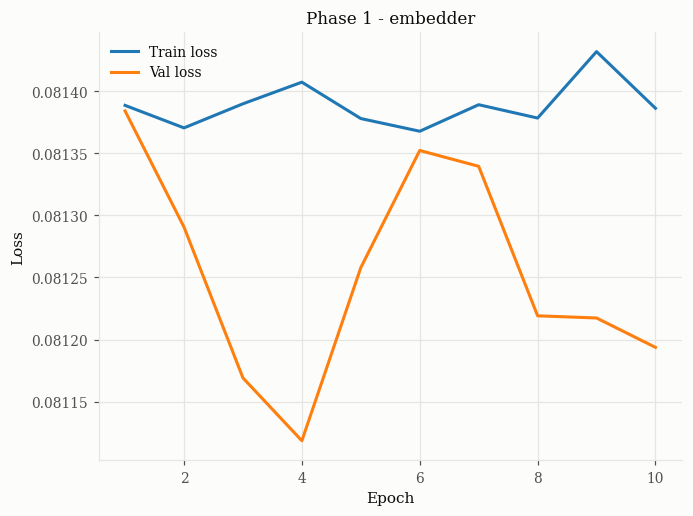


[intervene/train] === Phase 2: MLM pretraining ===
[InterveneEncoder]: Total params: 1.68 M

  pretrain_transformer  |  2026-09-06 06:13:17
  model config      : {'time2vec_dim': 32, 'embed_dim': 128, 'n_head': 2, 'n_layer': 4, 'dropout': 0.1, 'bias': True, 'ctx_dim': 43}
  training settings : {'phase1_n_epochs': 100, 'phase2_n_epochs': 100, 'phase3_n_epochs': 100, 'sample': None, 'lr_warmup_epochs': 5, 'early-stop-patience': 10, 'early-stop-min-delta-rel': 0.001, 'phase1_learning_rate': 0.0003, 'phase2_learning_rate': 0.0003, 'phase3_learning_rate': 0.0001, 'phase3_backbone_lr_factor': 0.1, 'phase3_weight_decay': 0.001, 'weight_decay': 0.001, 'dataloader_workers': 0, 'batch_size': 16, 'grad_accumulation_steps': 4, 'phase1_bce_window_hours': 3.0, 'phase2_terminal_bce_window_hours': 168.0, 'phase1_scheduler': {'main_only_epochs': 3, 'aux_fraction_caps': {'dt': 0.4}, 'order': [['dt']], 'ramp_epochs': {'dt': 0}, 'max_lambda': {'dt': 400.0}}, 'phase2_scheduler': {'main_only_epochs': 4, 'a

Training:   0%|          | 0/2196 [00:00<?, ?it/s]

Validation:   0%|          | 0/300 [00:00<?, ?it/s]

[Phase-2] Epoch 000  lr=3.259e-05
    --> Train=0.0000 (MLM=0.0000  tPos=0.0000  tLoc=0.0000)
    --> Val  =0.0000 (MLM=0.0000  tPos=0.0000  tLoc=0.0000)
   [timing] 2496 batches in 5.0 min (0.12 s/batch)  data=62% compute=38%  -> DATALOADER-BOUND  peak RSS=27.3 GB  gpu=1.0/14.6 GB


Training:   0%|          | 0/2196 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/300 [00:00<?, ?it/s]

[Phase-3] Epoch 018
    --> Train=0.2484 (Risk=0.2052  Time=0.4319)
    --> Val  =0.2658 (Risk=0.2213  Time=0.4455)
   [timing] 11501 batches in 15.9 min (0.08 s/batch)  data=53% compute=47%  -> mixed  peak RSS=28.2 GB  gpu=1.0/14.6 GB


Training:   0%|          | 0/11201 [00:00<?, ?it/s]

Validation:   0%|          | 0/300 [00:00<?, ?it/s]

[Phase-3] Epoch 019
    --> Train=0.2472 (Risk=0.2045  Time=0.4278)
    --> Val  =0.2595 (Risk=0.2156  Time=0.4388)
   [timing] 11501 batches in 15.8 min (0.08 s/batch)  data=53% compute=47%  -> mixed  peak RSS=28.2 GB  gpu=1.0/14.6 GB
[Phase-3]: Early stopping triggered.


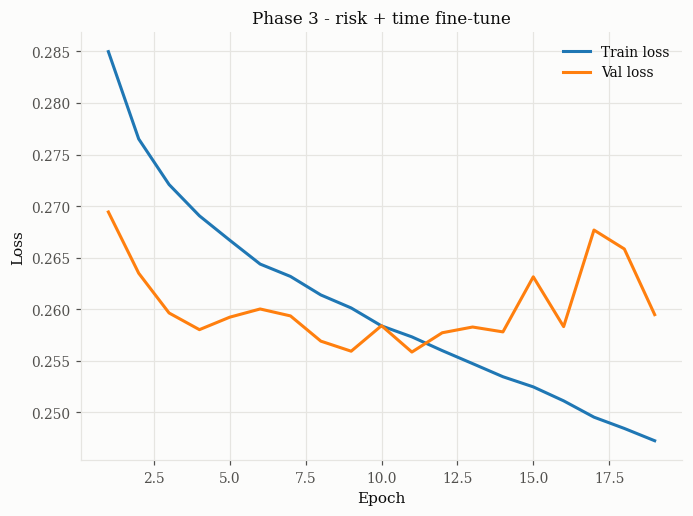


[intervene/train] === Test inference ===
[InterveneEncoder]: Total params: 1.68 M


Inference:   0%|          | 0/293 [00:00<?, ?it/s]


=== intervene_enc | K=4 | QA=False === (/workspace/notebooks/code/Predictions/kineret-prediction/outputs/intervene_enc/noqa)
                       outcome  n_pos  prevalence  auroc  auprc  best_f1  f1_0_5  minrp  time_mae_h  n_time  auroc_lo  auroc_hi  auprc_lo  auprc_hi  best_f1_lo  best_f1_hi  f1_0_5_lo  f1_0_5_hi  minrp_lo  minrp_hi  time_mae_h_lo  time_mae_h_hi  ci_reliable
CARDIO-VASCULAR_DISORDER_EVENT     69      0.0147 0.9568 0.5685   0.6626  0.6587 0.5949     36.3530      69    0.9161    0.9891    0.4576    0.7027      0.5963      0.7516     0.5698     0.7399    0.5088    0.7022        27.1127        46.6036         True
                   DEATH_EVENT    341      0.0728 0.9273 0.6454   0.6093  0.5233 0.5953     56.5549     341    0.9126    0.9407    0.5958    0.6934      0.5719      0.6537     0.4658     0.5735    0.5533    0.6388        52.5168        60.1376         True
           HYPERGLYCEMIA_EVENT   1470      0.3137 0.7570 0.5776   0.5913  0.4856 0.5407     25.3741    

Training:   0%|          | 0/2201 [00:00<?, ?it/s]

Validation:   0%|          | 0/300 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/300 [00:00<?, ?it/s]

[Phase-2] Epoch 099  lr=2.663e-04
    --> Train=2.4575 (MLM=2.3138  tPos=0.0033  tLoc=0.1404)
    --> Val  =2.0081 (MLM=1.8712  tPos=0.0032  tLoc=0.1336)
   [timing] 2496 batches in 5.6 min (0.13 s/batch)  data=60% compute=40%  -> mixed  peak RSS=29.3 GB  gpu=1.0/14.6 GB


Training:   0%|          | 0/2196 [00:00<?, ?it/s]

Validation:   0%|          | 0/300 [00:00<?, ?it/s]

[Phase-2] Epoch 100  lr=2.655e-04
    --> Train=2.4468 (MLM=2.3044  tPos=0.0032  tLoc=0.1391)
    --> Val  =2.0102 (MLM=1.8752  tPos=0.0039  tLoc=0.1311)
   [timing] 2496 batches in 5.6 min (0.13 s/batch)  data=60% compute=40%  -> mixed  peak RSS=29.3 GB  gpu=1.0/14.6 GB


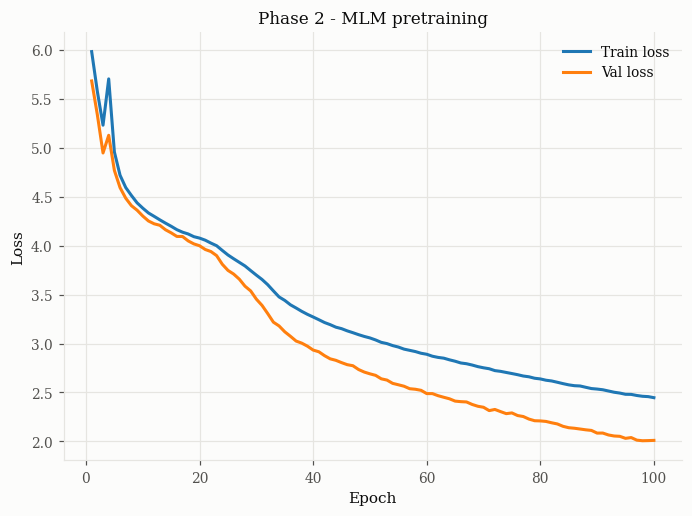


[intervene/train] === Phase 3: risk + time fine-tune ===

  finetune_transformer  |  2026-09-07 08:12:21
  model config      : {'time2vec_dim': 32, 'embed_dim': 128, 'n_head': 2, 'n_layer': 4, 'dropout': 0.1, 'bias': True, 'ctx_dim': 56}
  training settings : {'phase1_n_epochs': 100, 'phase2_n_epochs': 100, 'phase3_n_epochs': 100, 'sample': None, 'lr_warmup_epochs': 5, 'early-stop-patience': 10, 'early-stop-min-delta-rel': 0.001, 'phase1_learning_rate': 0.0003, 'phase2_learning_rate': 0.0003, 'phase3_learning_rate': 0.0001, 'phase3_backbone_lr_factor': 0.1, 'phase3_weight_decay': 0.001, 'weight_decay': 0.001, 'dataloader_workers': 0, 'batch_size': 16, 'grad_accumulation_steps': 4, 'phase1_bce_window_hours': 3.0, 'phase2_terminal_bce_window_hours': 168.0, 'phase1_scheduler': {'main_only_epochs': 3, 'aux_fraction_caps': {'dt': 0.4}, 'order': [['dt']], 'ramp_epochs': {'dt': 0}, 'max_lambda': {'dt': 400.0}}, 'phase2_scheduler': {'main_only_epochs': 4, 'aux_fraction_caps': {'t_pos': 0.4, '

time-stats:   0%|          | 0/11201 [00:00<?, ?it/s]

[Phase-3] per-outcome time stats (used inside the time loss only):
[Phase-3]   CARDIO-VASCULAR_DISORDER_EVENT   n_pos= 3048  mean= 128.99h  std=  66.69h
[Phase-3]   DEATH_EVENT                      n_pos=14197  mean= 205.19h  std=  77.61h
[Phase-3]   HYPERGLYCEMIA_EVENT              n_pos=60270  mean= 122.95h  std=  66.81h
[Phase-3]   HYPOGLYCEMIA_EVENT               n_pos= 6669  mean= 135.80h  std=  68.29h
[Phase-3]   INFECTION_EVENT                  n_pos= 2055  mean= 124.42h  std=  67.86h
[Phase-3]   KIDNEY_COMPLICATION_EVENT        n_pos=19917  mean= 144.27h  std=  71.82h
[Phase-3]   RELEASE_EVENT                    n_pos=179141  mean= 171.72h  std=  76.66h
[Phase-3]   SEVERE_HYPERGLYCEMIA_EVENT       n_pos=54615  mean= 120.80h  std=  65.77h
[Phase-3]   SEVERE_HYPOGLYCEMIA_EVENT        n_pos= 4543  mean= 137.18h  std=  69.47h


Training:   0%|          | 0/11201 [00:00<?, ?it/s]

Validation:   0%|          | 0/300 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/300 [00:00<?, ?it/s]

[Phase-3] Epoch 016
    --> Train=0.2423 (Risk=0.2001  Time=0.4221)
    --> Val  =0.2679 (Risk=0.2213  Time=0.4659)
   [timing] 11501 batches in 16.9 min (0.09 s/batch)  data=54% compute=46%  -> mixed  peak RSS=29.4 GB  gpu=1.0/14.6 GB


Training:   0%|          | 0/11201 [00:00<?, ?it/s]

Validation:   0%|          | 0/300 [00:00<?, ?it/s]

[Phase-3] Epoch 017
    --> Train=0.2404 (Risk=0.1986  Time=0.4183)
    --> Val  =0.2697 (Risk=0.2226  Time=0.4708)
   [timing] 11501 batches in 17.0 min (0.09 s/batch)  data=54% compute=46%  -> mixed  peak RSS=29.4 GB  gpu=1.0/14.6 GB
[Phase-3]: Early stopping triggered.


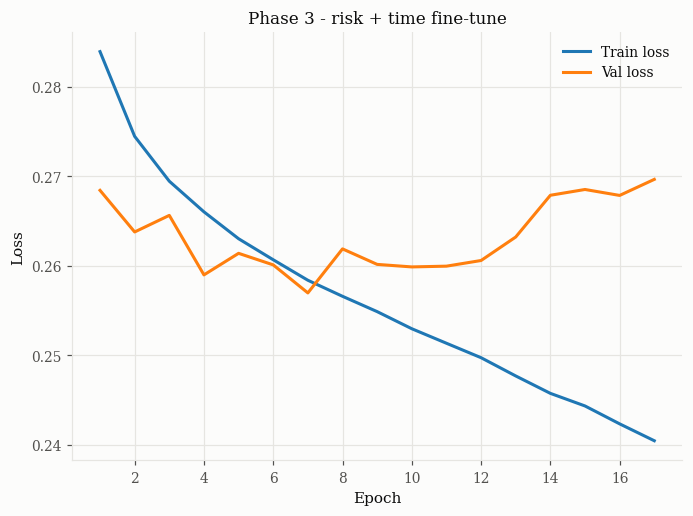


[intervene/train] === Test inference ===
[InterveneEncoder]: Total params: 1.69 M


Inference:   0%|          | 0/293 [00:00<?, ?it/s]


=== intervene_enc | K=4 | QA=True === (/workspace/notebooks/code/Predictions/kineret-prediction/outputs/intervene_enc/qa)
                       outcome  n_pos  prevalence  auroc  auprc  best_f1  f1_0_5  minrp  time_mae_h  n_time  auroc_lo  auroc_hi  auprc_lo  auprc_hi  best_f1_lo  best_f1_hi  f1_0_5_lo  f1_0_5_hi  minrp_lo  minrp_hi  time_mae_h_lo  time_mae_h_hi  ci_reliable
CARDIO-VASCULAR_DISORDER_EVENT     69      0.0147 0.9569 0.5000   0.6304  0.6230 0.5366     35.9273      69    0.9188    0.9875    0.3885    0.6273      0.5605      0.7151     0.5393     0.7006    0.4423    0.6418        26.4449        46.6359         True
                   DEATH_EVENT    341      0.0728 0.9165 0.6093   0.5884  0.5651 0.5743     57.4345     341    0.9009    0.9305    0.5556    0.6598      0.5534      0.6350     0.5167     0.6120    0.5358    0.6225        53.1905        61.2683         True
           HYPERGLYCEMIA_EVENT   1470      0.3137 0.7597 0.5954   0.5931  0.4147 0.5541     25.6785    147

,label,status,minutes
0,LogReg (raw),skipped,0.00
1,LogReg (raw + QA),skipped,0.00
2,ss-STraTS (raw),skipped,0.00
3,ss-STraTS (raw + QA),skipped,0.00
4,INTERVenE-Enc (σ-bins),skipped,0.00
5,INTERVenE-Enc (KB),ok,915.59
6,INTERVenE-Enc (KB + QA),ok,1022.34


In [10]:
from kineret.benchmark import run_ladder

ladder_report = run_ladder(
    arms=None,                    # None = all seven, in ladder order
    device=DEVICE,
    bootstrap_resamples=BOOTSTRAP,
    skip_existing=True,           # <- the resume switch
)
save_table(ladder_report, "run_ladder_log")
free_memory(verbose=True)
ladder_report[["label", "status", "minutes"]]

## 6 · The ladder

The study's central claim, as one table and one figure:

> raw measurements < knowledge-free intervals < KB abstractions < KB + treatment patterns

Every number carries a 95 % interval from a 2 000-resample **patient-level
bootstrap** on the held-out split. **Adjacent rungs whose intervals overlap have
not been separated by this data** — the figure is a dot-and-interval plot rather
than a bar chart for exactly that reason.

In [11]:
from kineret.benchmark import check_label_agreement, ladder_table, load_results

# Re-assert the invariant on the REAL runs, not just the smoke test.
agreement = check_label_agreement()
assert agreement["labels_identical"], agreement["detail"]

ladder = ladder_table(average="weighted")
save_table(ladder, f"ladder_weighted_k{C.EVAL_CONTEXT_DAYS}")
ladder

[check] 6 arm pair(s) compared -- labels and test patients identical in every one.
[table]  /workspace/notebooks/code/Predictions/kineret-prediction/outputs/figures/ladder_weighted_k4.csv


,Rung,Arm,n_test,AUROC,AUPRC,BEST_F1,Onset MAE (h),LoS MAE (h)
0,1,LogReg (raw),4686,"0.754 [0.743, 0.764]","0.452 [0.436, 0.472]","0.527 [0.517, 0.542]","32.9 [31.7, 34.0]","47.7 [46.6, 48.7]"
1,2,LogReg (raw + QA),4686,"0.754 [0.743, 0.764]","0.450 [0.434, 0.469]","0.530 [0.519, 0.545]","33.1 [32.0, 34.3]","47.7 [46.6, 48.7]"
2,3,ss-STraTS (raw),4686,"0.772 [0.762, 0.781]","0.472 [0.456, 0.493]","0.535 [0.525, 0.551]","33.2 [32.2, 34.3]","46.4 [45.3, 47.4]"
3,4,ss-STraTS (raw + QA),4686,"0.771 [0.762, 0.781]","0.471 [0.455, 0.491]","0.532 [0.523, 0.547]","32.8 [31.8, 34.0]","47.7 [46.6, 48.7]"
4,5,INTERVenE-Enc (σ-bins),4686,"0.755 [0.744, 0.765]","0.454 [0.438, 0.473]","0.518 [0.508, 0.534]","33.3 [32.3, 34.4]","45.1 [44.1, 46.1]"
5,6,INTERVenE-Enc (KB),4686,"0.805 [0.795, 0.813]","0.527 [0.511, 0.548]","0.561 [0.553, 0.578]","30.8 [29.7, 31.8]","45.9 [44.8, 46.9]"
6,7,INTERVenE-Enc (KB + QA),4686,"0.802 [0.793, 0.811]","0.535 [0.518, 0.554]","0.557 [0.547, 0.573]","30.9 [29.8, 31.9]","46.0 [44.9, 47.0]"


[figure] /workspace/notebooks/code/Predictions/kineret-prediction/outputs/figures/fig2_ladder.png
[table]  /workspace/notebooks/code/Predictions/kineret-prediction/outputs/figures/fig2_ladder.csv


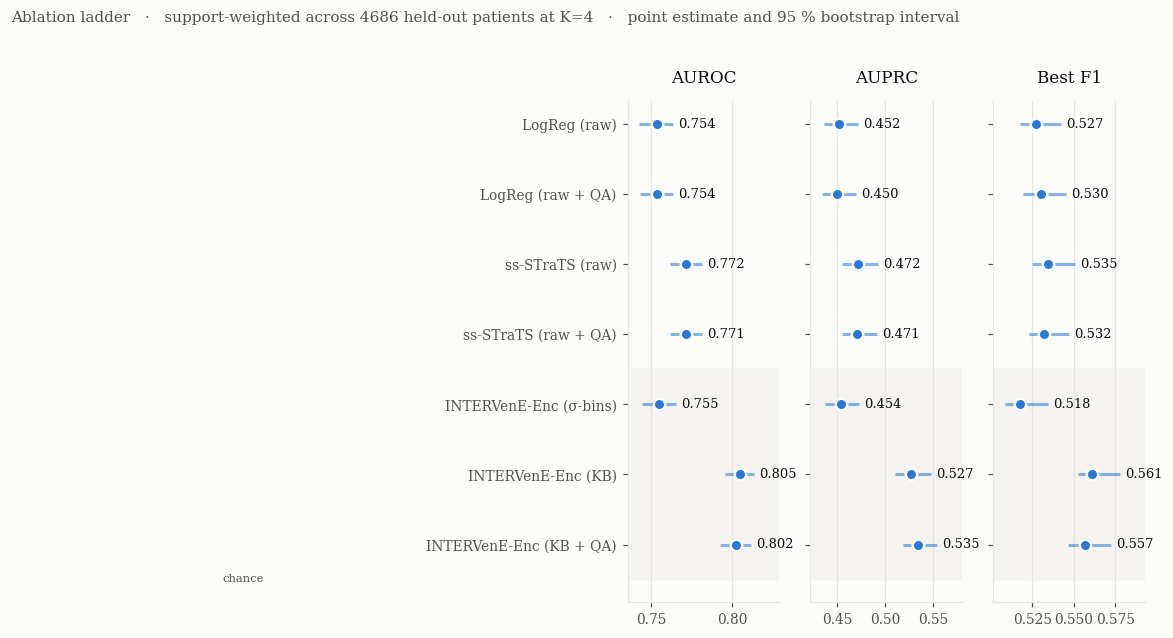

In [12]:
figures.plot_ladder(average="weighted");

In [13]:
# Macro average: every target weighted equally, so the rare complications count
# as much as the common ones. Weighted and macro disagreeing tells you the arms
# differ mostly on the rare tail.
macro = ladder_table(average="macro")
save_table(macro, f"ladder_macro_k{C.EVAL_CONTEXT_DAYS}")
macro

[table]  /workspace/notebooks/code/Predictions/kineret-prediction/outputs/figures/ladder_macro_k4.csv


,Rung,Arm,n_test,AUROC,AUPRC,BEST_F1,Onset MAE (h),LoS MAE (h)
0,1,LogReg (raw),4686,"0.826 [0.812, 0.839]","0.367 [0.350, 0.393]","0.442 [0.428, 0.468]","39.9 [37.1, 42.5]","47.7 [46.6, 48.7]"
1,2,LogReg (raw + QA),4686,"0.822 [0.807, 0.836]","0.364 [0.347, 0.390]","0.442 [0.427, 0.468]","41.1 [38.1, 44.0]","47.7 [46.6, 48.7]"
2,3,ss-STraTS (raw),4686,"0.828 [0.815, 0.841]","0.375 [0.355, 0.399]","0.430 [0.417, 0.457]","37.7 [35.4, 40.3]","46.4 [45.3, 47.4]"
3,4,ss-STraTS (raw + QA),4686,"0.820 [0.806, 0.834]","0.365 [0.346, 0.392]","0.427 [0.411, 0.455]","39.7 [37.3, 42.3]","47.7 [46.6, 48.7]"
4,5,INTERVenE-Enc (σ-bins),4686,"0.810 [0.794, 0.824]","0.332 [0.317, 0.356]","0.401 [0.386, 0.431]","37.0 [34.8, 39.4]","45.1 [44.1, 46.1]"
5,6,INTERVenE-Enc (KB),4686,"0.847 [0.831, 0.861]","0.402 [0.385, 0.428]","0.454 [0.443, 0.483]","36.1 [34.0, 38.4]","45.9 [44.8, 46.9]"
6,7,INTERVenE-Enc (KB + QA),4686,"0.841 [0.824, 0.855]","0.403 [0.383, 0.433]","0.451 [0.436, 0.480]","35.8 [33.6, 38.1]","46.0 [44.9, 47.0]"


## 7 · The other two questions

Onset timing and length of stay. **Lower is better** in both panels, which is
why they are plotted apart from the risk metrics.

Onset is conditional on occurrence — only positive patients contribute — so on a
rare target the interval reflects which few patients were drawn rather than
model uncertainty. §7 reports `n_pos` and `ci_reliable` next to every figure.

[figure] /workspace/notebooks/code/Predictions/kineret-prediction/outputs/figures/fig5_onset_and_los.png
[table]  /workspace/notebooks/code/Predictions/kineret-prediction/outputs/figures/fig5_onset_and_los.csv


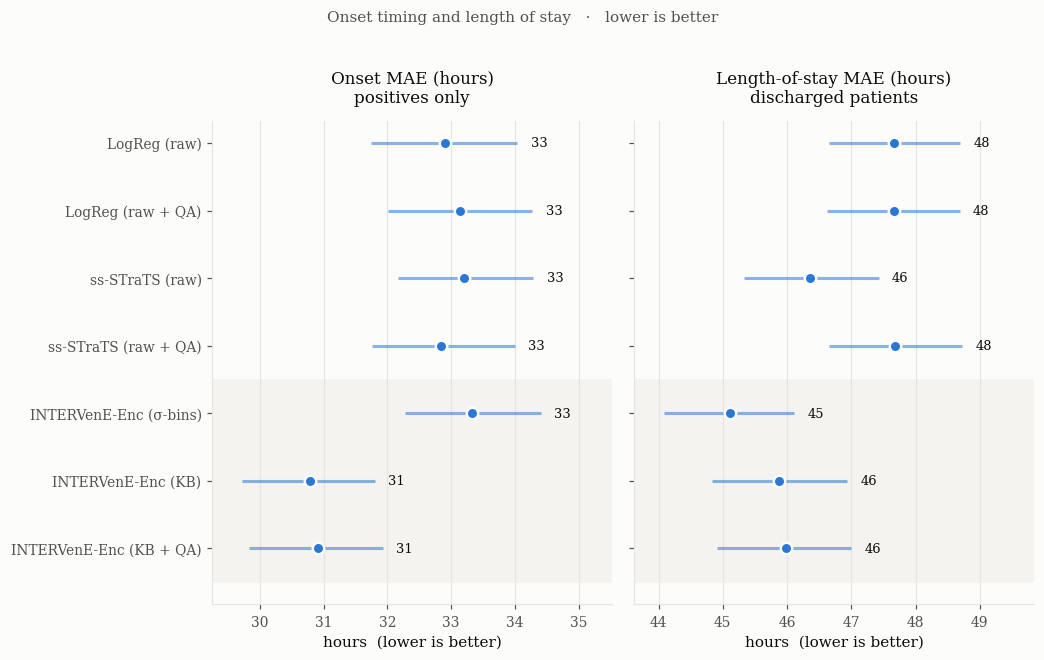

In [14]:
figures.plot_error_heads(average="weighted");

## 8 · Does the QA signal help?

Each model's two arms differ by **exactly** the aggregated `QA_<pattern>`
context block — same patients, same labels, same events, same seed — plus, for
INTERVenE only, the pattern token stream it can natively represent. So a
positive delta is attributable to the treatment-quality signal.

A delta narrower than the intervals in §5 is noise, not a finding.

In [15]:
from kineret.benchmark import qa_delta_table

qa_delta = qa_delta_table(average="weighted")
save_table(qa_delta, "qa_delta")
qa_delta

[table]  /workspace/notebooks/code/Predictions/kineret-prediction/outputs/figures/qa_delta.csv


,Model,Metric,no QA,with QA,delta
0,LogReg,AUROC,0.753654,0.753804,0.000150
1,LogReg,AUPRC,0.452192,0.450016,-0.002176
2,LogReg,BEST_F1,0.527112,0.530000,0.002888
3,ss-STraTS,AUROC,0.771809,0.771429,-0.000380
4,ss-STraTS,AUPRC,0.472460,0.471296,-0.001164
5,ss-STraTS,BEST_F1,0.534638,0.531719,-0.002919
6,INTERVenE-Enc (KB),AUROC,0.804673,0.802234,-0.002439
7,INTERVenE-Enc (KB),AUPRC,0.527356,0.534625,0.007270
8,INTERVenE-Enc (KB),BEST_F1,0.561067,0.556815,-0.004252


[figure] /workspace/notebooks/code/Predictions/kineret-prediction/outputs/figures/fig3_qa_delta.png
[table]  /workspace/notebooks/code/Predictions/kineret-prediction/outputs/figures/fig3_qa_delta.csv


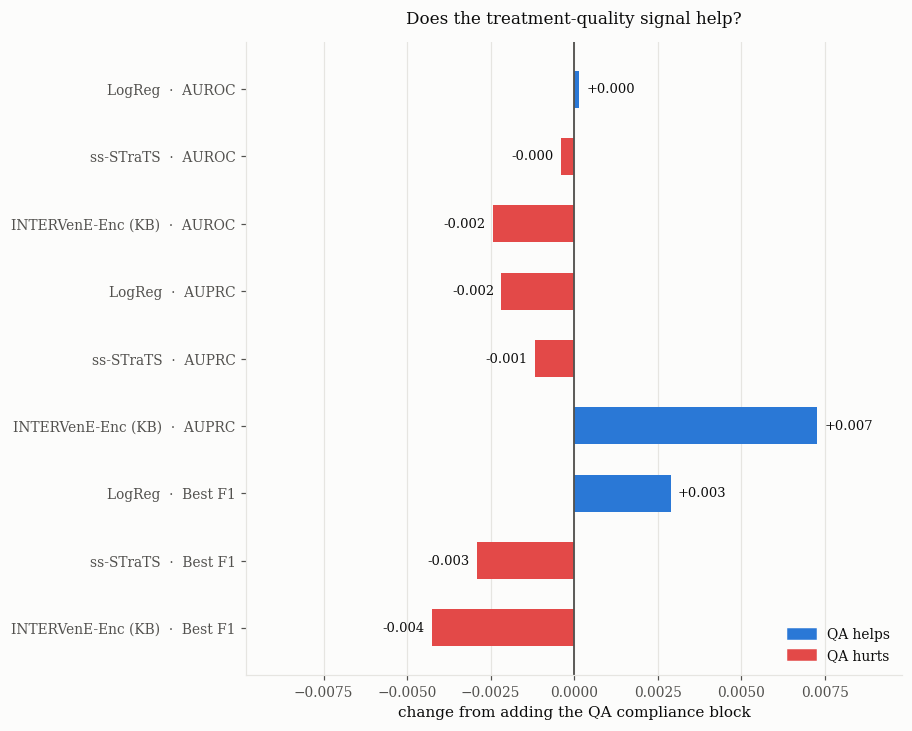

In [16]:
figures.plot_qa_delta(qa_delta);

## 9 · Per-target breakdown

Where does any advantage actually come from? `n_pos` is the positive support on
the held-out split and `ci_reliable` flags targets with too few positives for an
interval to mean much — treat a strong number on a single-digit-support target
as noise, not a result.

In [17]:
from kineret.benchmark import per_outcome_table

per_auprc = per_outcome_table(metric="auprc")
save_table(per_auprc.reset_index(), "per_target_auprc")
per_auprc

[table]  /workspace/notebooks/code/Predictions/kineret-prediction/outputs/figures/per_target_auprc.csv


,n_pos,ci_reliable,LogReg (raw),LogReg (raw + QA),ss-STraTS (raw),ss-STraTS (raw + QA),INTERVenE-Enc (σ-bins),INTERVenE-Enc (KB),INTERVenE-Enc (KB + QA)
outcome,,,,,,,,,
HYPERGLYCEMIA_EVENT,1470,True,0.449506,0.448924,0.486117,0.492768,0.459072,0.577562,0.595356
SEVERE_HYPERGLYCEMIA_EVENT,1317,True,0.438969,0.436218,0.471659,0.463346,0.448809,0.512776,0.515702
KIDNEY_COMPLICATION_EVENT,566,True,0.589719,0.587958,0.578045,0.575517,0.604815,0.586549,0.606113
DEATH_EVENT,341,True,0.587107,0.580952,0.559434,0.572957,0.576507,0.645391,0.609258
HYPOGLYCEMIA_EVENT,181,True,0.135491,0.132473,0.137854,0.130199,0.119464,0.149137,0.163402
SEVERE_HYPOGLYCEMIA_EVENT,111,True,0.104393,0.103371,0.104441,0.102246,0.085337,0.118505,0.132788
CARDIO-VASCULAR_DISORDER_EVENT,69,True,0.563736,0.555847,0.583342,0.508177,0.295298,0.568469,0.500026
INFECTION_EVENT,37,True,0.067034,0.063635,0.075844,0.077000,0.066746,0.058396,0.100018


[figure] /workspace/notebooks/code/Predictions/kineret-prediction/outputs/figures/fig4_per_target_auprc.png
[table]  /workspace/notebooks/code/Predictions/kineret-prediction/outputs/figures/fig4_per_target_auprc.csv


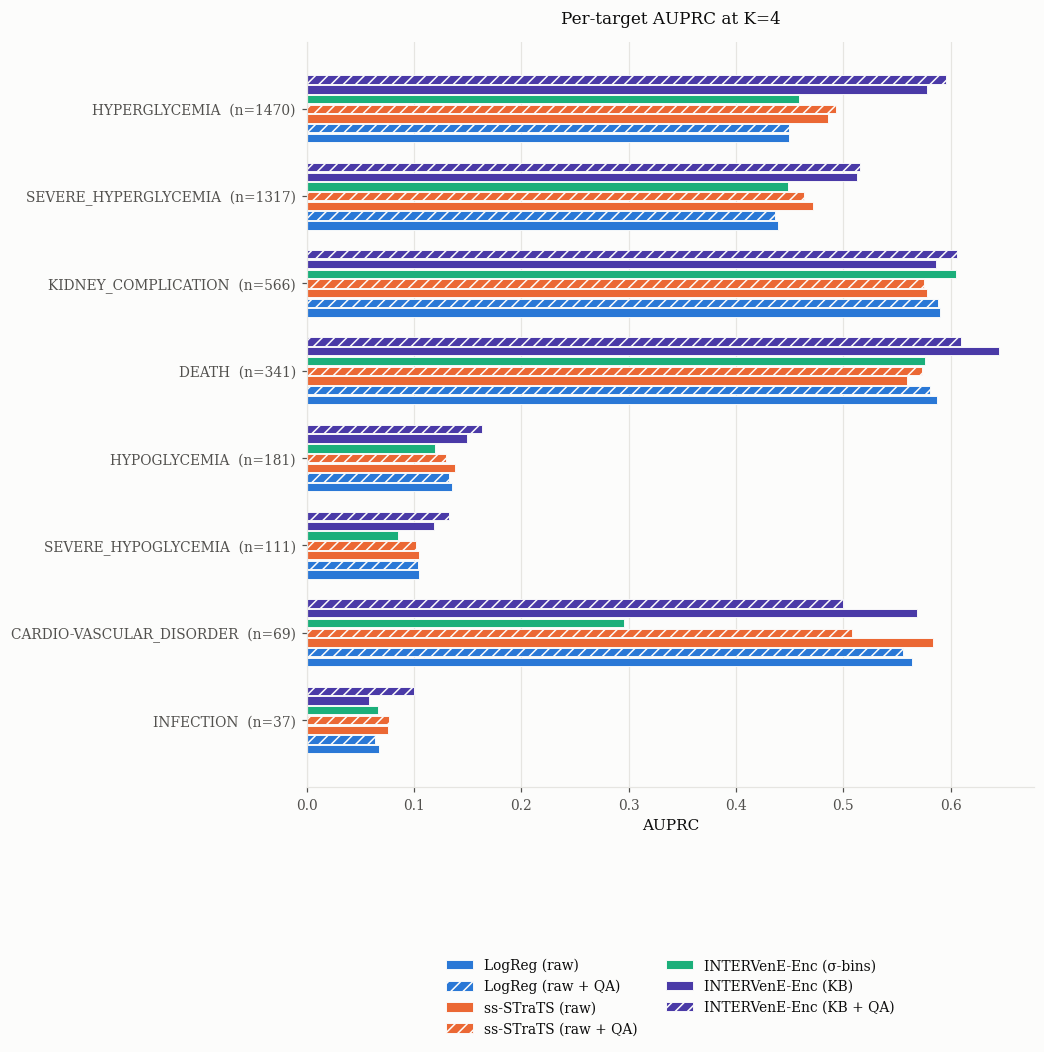

In [18]:
figures.plot_per_target(metric="auprc");

[figure] /workspace/notebooks/code/Predictions/kineret-prediction/outputs/figures/fig4_per_target_auroc.png
[table]  /workspace/notebooks/code/Predictions/kineret-prediction/outputs/figures/fig4_per_target_auroc.csv


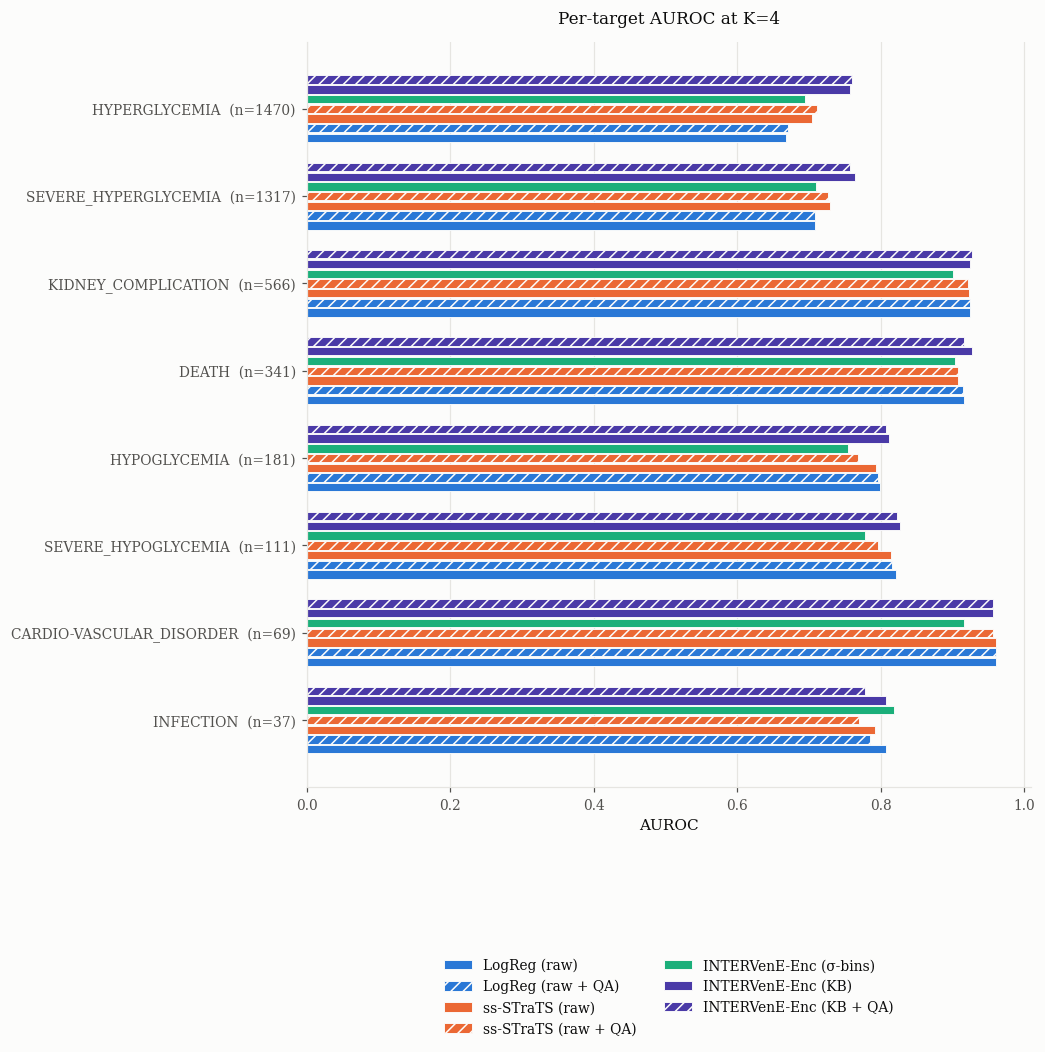

In [19]:
figures.plot_per_target(metric="auroc");

## 10 · Export

Everything for the paper is already in `outputs/figures/` — each figure as PNG
and PDF, with the table behind it as CSV.

In [20]:
import json

results = load_results(average="weighted")
results.to_csv(os.path.join(paths.OUTPUT_DIR, "benchmark_summary.csv"), index=False)
with open(os.path.join(paths.OUTPUT_DIR, "study_config.json"), "w") as f:
    json.dump({k: (list(v) if isinstance(v, tuple) else v)
               for k, v in study.items()}, f, indent=2, default=str)

print(f"Artefacts in {paths.FIGURE_DIR}:")
for entry in sorted(os.listdir(paths.FIGURE_DIR)):
    print(f"  {entry}")
free_memory(verbose=True)
results

Artefacts in /workspace/notebooks/code/Predictions/kineret-prediction/outputs/figures:
  .gitkeep
  cohort_event_audit.csv
  fig1_target_support.csv
  fig1_target_support.pdf
  fig1_target_support.png
  fig2_ladder.csv
  fig2_ladder.pdf
  fig2_ladder.png
  fig3_qa_delta.csv
  fig3_qa_delta.pdf
  fig3_qa_delta.png
  fig4_per_target_auprc.csv
  fig4_per_target_auprc.pdf
  fig4_per_target_auprc.png
  fig4_per_target_auroc.csv
  fig4_per_target_auroc.pdf
  fig4_per_target_auroc.png
  fig5_onset_and_los.csv
  fig5_onset_and_los.pdf
  fig5_onset_and_los.png
  ladder_macro_k4.csv
  ladder_weighted_k4.csv
  per_target_auprc.csv
  qa_delta.csv
  rule_agreement.csv
  run_ladder_log.csv
[memory] GPU reserved 0.03 -> 0.03 GiB


,arm,label,rung,n_test,n_train_samples,context_days,run_dir,auroc,auroc_lo,auroc_hi,...,f1_0_5_hi,minrp,minrp_lo,minrp_hi,onset_mae_h,onset_mae_h_lo,onset_mae_h_hi,los_mae_h,los_mae_h_lo,los_mae_h_hi
0,logreg,LogReg (raw),1,4686,179141,4,logreg/noqa,0.753654,0.742757,0.763608,...,0.495936,0.462743,0.448700,0.478108,32.906168,31.745217,34.033941,47.662324,46.649832,48.692670
1,logreg_qa,LogReg (raw + QA),2,4686,179141,4,logreg/qa,0.753804,0.743108,0.763811,...,0.497676,0.456209,0.442683,0.473155,33.145143,32.014581,34.269949,47.662724,46.628747,48.686137
2,strats,ss-STraTS (raw),3,4686,179141,4,strats/noqa,0.771809,0.761643,0.781421,...,0.504135,0.472122,0.457822,0.490563,33.195722,32.165402,34.285140,46.353922,45.336655,47.423577
3,strats_qa,ss-STraTS (raw + QA),4,4686,179141,4,strats/qa,0.771429,0.761685,0.781094,...,0.516818,0.472801,0.458786,0.491561,32.848097,31.765629,33.993488,47.686169,46.649880,48.728628
4,intervene_std,INTERVenE-Enc (σ-bins),5,4686,179141,4,intervene_enc_std/noqa,0.755089,0.744446,0.765311,...,0.350412,0.462061,0.446495,0.478201,33.325099,32.268911,34.402724,45.113206,44.084130,46.108039
5,intervene_kb,INTERVenE-Enc (KB),6,4686,179141,4,intervene_enc/noqa,0.804673,0.795128,0.813219,...,0.449843,0.515770,0.503335,0.533036,30.782549,29.721444,31.798419,45.876753,44.838802,46.931032
6,intervene_kb_qa,INTERVenE-Enc (KB + QA),7,4686,179141,4,intervene_enc/qa,0.802234,0.792541,0.811338,...,0.400627,0.516883,0.504177,0.534598,30.910934,29.824553,31.926526,45.978240,44.914002,46.999753
